In [2]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [4]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [5]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [7]:
# users
user_features_numpy[:,0]

array([1, 1, 1, ..., 1, 0, 0])

In [8]:
# users
item_features_numpy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [9]:
dataset = rating_data
unique_categories.__len__()

21

In [10]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
model_1 = UserKNN(k=20, seed=123, verbose=True)
model_2 = ItemKNN(k=20, seed=123, verbose=True)
model_3 =MF(
            k=20,
            seed=123,
            name=f"a={3} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=128,
            alpha=0.3,
            learning_rate=0.001,
            top_k=50, max_iter=15,run_mode="bce",
            # early_stopping=True
        )
model_4 = VAECF(
            k=20,
            autoencoder_structure=[60,32],
            act_fn="relu",
            likelihood="bern",
            n_epochs=50,
            batch_size=128,
            learning_rate=0.0005,
            alpha=0.3,
            top_k=50,
            beta=1,
            name=f"a={3} vae",
            seed=123,
            verbose=True,
            # early_stopping=True
        )
model_5 = NeuMF(num_factors=8,seed=123, layers=[32,16,8], act_fn="sigmoid", num_epochs=51, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=0.4, top_k=50, name=str(4)+ "neumf")
 
# models.append(model_1)
# models.append(model_2)
models.append(model_3)
models.append(model_4)
models.append(model_5)
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 15/15 [01:42<00:00,  6.83s/it, loss=0.589]


[75.11324310302734, 75.11578369140625, 75.11970520019531, 75.11387634277344, 75.11554718017578, 75.13956451416016, 75.12275695800781, 75.15763092041016, 75.16212463378906, 75.13800811767578, 75.1666259765625, 75.19109344482422, 75.15215301513672, 75.15485382080078, 75.18334197998047, 75.16395568847656, 75.1952133178711, 75.18540954589844, 75.2095718383789, 75.16320037841797, 75.24321746826172, 75.14543914794922, 75.20094299316406, 75.1512680053711, 75.25128173828125, 75.1906509399414, 75.17083740234375, 75.22250366210938, 75.20284271240234, 75.23770904541016, 75.16094207763672, 75.24320983886719, 75.17747497558594, 75.18846893310547, 75.19468688964844, 75.2369155883789, 75.26321411132812, 75.22434997558594, 75.33132934570312, 75.13912963867188, 75.10374450683594, 75.1753158569336, 75.11907958984375, 75.16781616210938, 75.19644927978516, 75.19440460205078, 75.32302856445312, 75.12013244628906, 75.24590301513672, 75.1624755859375, 75.27630615234375, 75.17034912109375, 75.18464660644531, 

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 2337.82it/s]



[a=3 vae] Training started!


...


[4neumf] Training started!


100%|██████████| 51/51 [40:00<00:00, 47.07s/it, loss=0.543]   


[0.5448819398880005, 0.5448436737060547, 0.5447924733161926, 0.544684886932373, 0.5446606278419495, 0.5445312857627869, 0.5444636344909668, 0.5444434881210327, 0.5443974733352661, 0.5443264245986938, 0.5443258285522461, 0.5442870259284973, 0.5442997217178345, 0.5442144870758057, 0.544196367263794, 0.5442528128623962, 0.5442075729370117, 0.5441669225692749, 0.5442569255828857, 0.5441722273826599, 0.5441651940345764, 0.5441569685935974, 0.5441681146621704, 0.5441914200782776, 0.5441702604293823, 0.5441882610321045, 0.5441567301750183, 0.544188916683197, 0.544170618057251, 0.5441586971282959, 0.5441529750823975, 0.544150710105896, 0.5441434383392334, 0.5441555976867676, 0.5441582202911377, 0.5441661477088928, 0.544159471988678, 0.5441609025001526, 0.5441651940345764, 0.5441703796386719, 0.5441430807113647, 0.5441418290138245, 0.5441534519195557, 0.5441411137580872, 0.5441350936889648, 0.5441327691078186, 0.5441291928291321, 0.5441405177116394, 0.5441655516624451, 0.5441336631774902, 0.544

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 1398.19it/s]


VALIDATION:
...
        |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Time (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------
a=3 mf  | 0.6375 | 0.0285 |      0.5502 | 0.0260 | 0.0882 |  0.0584 |       0.0174 |    0.1071 |   0.5646
a=3 vae | 0.6282 | 0.0334 |      0.6049 | 0.0315 | 0.1105 |  0.0738 |       0.0202 |    0.1278 |   0.7313
4neumf  | 0.6270 | 0.0359 |      0.6201 | 0.0310 | 0.1042 |  0.0760 |       0.0217 |    0.1362 |   0.9427

TEST:
...
        |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=3 mf  | 0.6392 | 0.0488 |      0.7500 | 0.0382 | 0.1438 |  0.0773 |       0.0341 |    0.1100 |  102.8598 |   0.5985
a=3 vae | 0.6290 | 0.0568 |      0.8032 | 0.0438 | 0.1829 |  0.0961 |       0.0390 |    

In [11]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [15]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [18]:
# new_reco_matrix = np.zeros((5, len(user_ids), top_k), dtype=int)
# new_reco_matrix_all = np.zeros((5, len(user_ids), len(item_ids)), dtype=int)
# new_reco_matrix[0] = reco_matrix_old[0] #iknn
# new_reco_matrix[1] = reco_matrix_old[1] #userknn
# new_reco_matrix[2] = reco_matrix[0] #mf
# new_reco_matrix[3] = reco_matrix_old[3] #vaecf
# new_reco_matrix[4] = reco_matrix_old[4] #neumf

# new_reco_matrix_all[0] = reco_matrix_all_old[0] #iknn
# new_reco_matrix_all[1] = reco_matrix_all_old[1] #userknn
# new_reco_matrix_all[2] = reco_matrix_all[0] #mf
# new_reco_matrix_all[3] = reco_matrix_all_old[3] #vaecf
# new_reco_matrix_all[4] = reco_matrix_all_old[4] #neumf
new_reco_matrix_all = reco_matrix_all
new_reco_matrix = reco_matrix

In [13]:
np.save("reco_matrix_uknn_iknn.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_uknn_iknn.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [16]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)
gr = GenreRecall(users, unique_categories, top_k)
gm = GenreMapEdited(users, unique_categories, top_k)
gndcg = GenreNDCG(users, unique_categories, top_k)
gmrr = GenreMRR(users, unique_categories, top_k)

In [19]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(new_reco_matrix)):
    ####Precision####
    model_gps.append(gp.compute(new_reco_matrix[i], restaurants))
    model_grs.append(gr.compute(new_reco_matrix[i], restaurants))
    model_gms.append(gm.compute(new_reco_matrix[i], restaurants))
    model_gdcgs.append(gndcg.compute(new_reco_matrix[i], restaurants))
    model_gmrrs.append(gmrr.compute(new_reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [20]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = restaurants[unique_categories].div(restaurants[unique_categories].sum(axis=1), axis=0)
movies_df = movies_df[unique_categories].sum()
import math
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(new_reco_matrix), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(new_reco_matrix)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = new_reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_categories, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [21]:
model_grps = []
for i in range(len(new_reco_matrix)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, restaurants))

        Active Life & Fitness  Arts & Entertainment  Automotive  \
Gender                                                            
0                    0.000000              0.042298         0.0   
1                    0.000019              0.039849         0.0   

        Bars & Nightlife  Coffee,Tea & Desserts  Drinks & Spirits  \
Gender                                                              
0               0.114694               0.072693          0.013815   
1               0.114046               0.073953          0.014164   

        Education & Learning  Event Services  Family & Kids  \
Gender                                                        
0                        0.0        0.031082            0.0   
1                        0.0        0.030164            0.0   

        Food & Restaurants  ...  Home & Garden  Miscellaneous  \
Gender                      ...                                 
0                 0.533396  ...            0.0            0.0   
1     

In [ ]:
model_grps.__len__()

3

In [22]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(reco_matrix))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(reco_matrix))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(reco_matrix))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(reco_matrix))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(reco_matrix))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(reco_matrix))]


In [23]:
from operator import itemgetter

# unique_genres
indices = [4, 1, 19, 20]

compare_genres = itemgetter(*indices)(unique_categories)
# compare_genres = unique_genres
# indices = range(18)
# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99999999999]

list(compare_genres)

['Coffee,Tea & Desserts',
 'Arts & Entertainment',
 'Travel & Transportation',
 'Asian']

In [24]:
compare_genres = ['Coffee,Tea & \nDesserts',
 'Arts &\n Entertainment',
 'Travel & \nTransportation',
 'Asian']

['MF', 'MF_a=0.5', 'VAECF', 'VAECF_a=0.3', 'NeuMF', 'NeuMF_a=0.2']
[<BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>, <BarContainer object of 4 artists>]


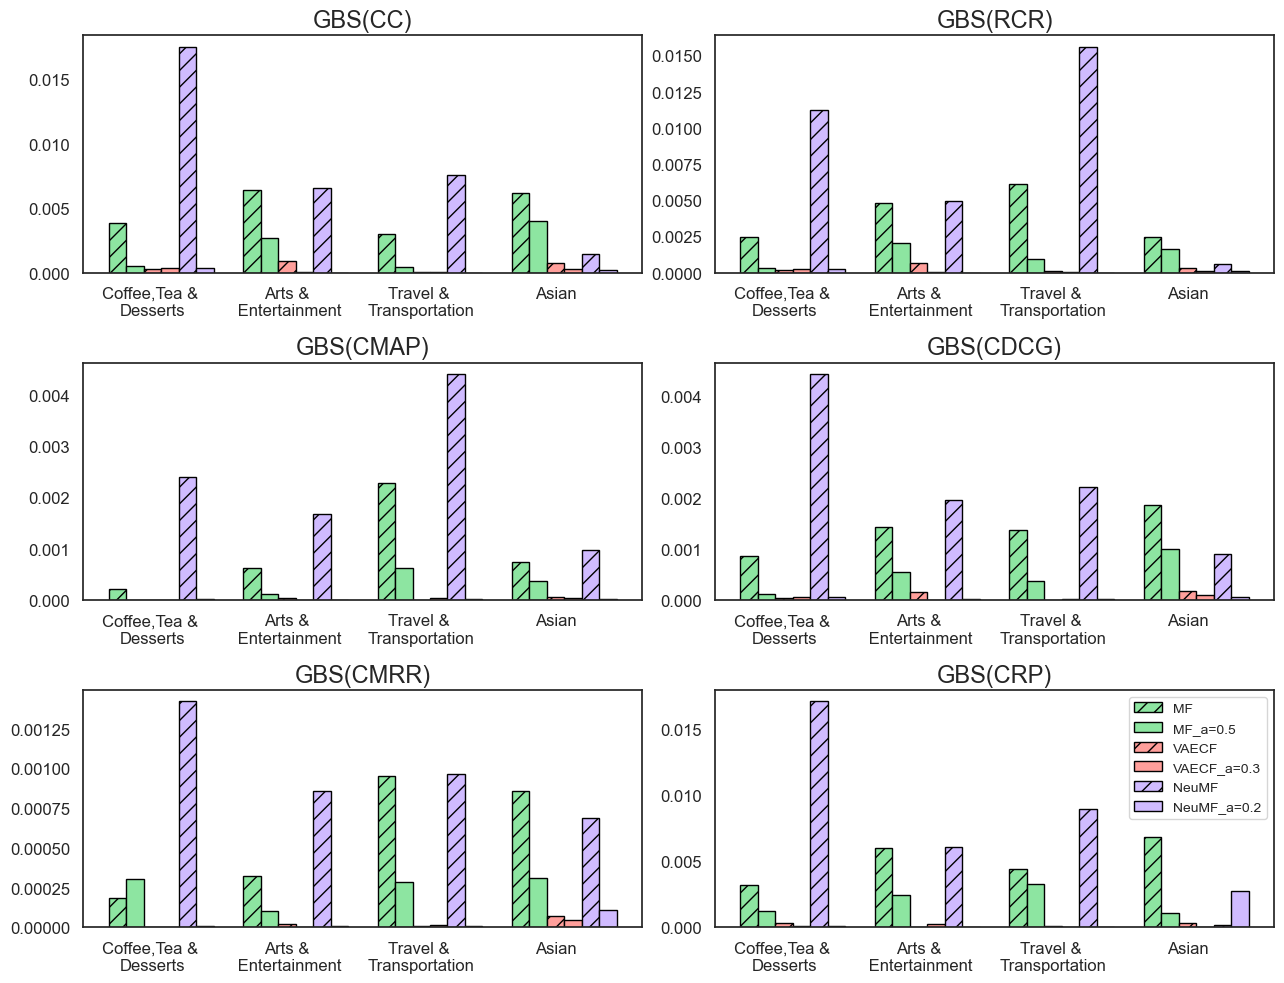

In [27]:
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="white")
pastel_colors = sns.color_palette("pastel")

# alpha_values =[0,0.1,0.2,0.3,0.4,0.5,0.6]
matrices_mfreg = [
 model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
 
matrices_mf0= [
   yelp_dataset[2][0],
    yelp_dataset[2][1],
   yelp_dataset[2][2],
    yelp_dataset[2][3],
    yelp_dataset[2][4],
    yelp_dataset[2][5],
]
matrices_vae0 = [
    yelp_dataset[3][0],
    yelp_dataset[3][1],
   yelp_dataset[3][2],
    yelp_dataset[3][3],
    yelp_dataset[3][4],
    yelp_dataset[3][5],
]
matrices_vaereg = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_neumf0 = [
    yelp_dataset[4][0],
    yelp_dataset[4][1],
   yelp_dataset[4][2],
    yelp_dataset[4][3],
    yelp_dataset[4][4],
    yelp_dataset[4][5],
]
matrices_neureg = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]

labels = compare_genres
titles = [
    "GBS(CC)",
    "GBS(RCR)",
    "GBS(CMAP)",
    "GBS(CDCG)",
    "GBS(CMRR)",
    "GBS(CRP)",
]


fig, axs = plt.subplots(3,2, figsize=(13, 10))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.13  # the width of the bars
bar_spacing =0.0
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
hatches = ['//', '\\\\', '||', '--', '++']

for i in range(len(titles)):
    axs[i].bar(
        x - 2 * (bar_width + bar_spacing), abs(matrices_mf0[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', hatch=hatches[0], label="MF"
    )
    axs[i].bar(
        x - 1 * (bar_width + bar_spacing), abs(matrices_mfreg[i]), bar_width, color=pastel_colors[2],
        edgecolor='black', label="MF_a=0.5"
    )
    axs[i].bar(
        x + 0 * (bar_width + bar_spacing), abs(matrices_vae0[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', hatch=hatches[0], label="VAECF"
    )
    axs[i].bar(
        x + 1 * (bar_width + bar_spacing), abs(matrices_vaereg[i]), bar_width, color=pastel_colors[3],
        edgecolor='black', label="VAECF_a=0.3"
    )
    axs[i].bar(
        x + 2 * (bar_width + bar_spacing), abs(matrices_neumf0[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', hatch=hatches[0], label="NeuMF"
    )
    axs[i].bar(
        x + 3 * (bar_width + bar_spacing), abs(matrices_neureg[i]), bar_width, color=pastel_colors[4],
        edgecolor='black', label="NeuMF_a=0.2"
    )
    
    axs[i].set_xticks(x)
    # axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=17)
    # axs[i].set_yticklabels( fontsize=17)
    # axs[i].tick_params(axis="y", labelsize =12)
    axs[i].set_xticklabels(compare_genres, rotation=0, fontsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    # axs[i].set_y
    axs[i].set_title(titles[i], fontsize =17)
    # axs[i].set_xlabel("Genres")
    # axs[i].set_ylabel("Values")
    
    


handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)


plt.legend(handles, labels, loc="upper right", fontsize="small")
# Adjust layout
plt.tight_layout()
plt.savefig("all_models_reg.pdf", format="pdf")

plt.show()

In [33]:
np.array(matrices_neureg)

array([[-3.49966033e-04,  0.00000000e+00,  0.00000000e+00,
         2.29329652e-04],
       [-2.24693858e-04,  0.00000000e+00,  0.00000000e+00,
         9.17440933e-05],
       [-1.30449135e-05,  5.62015384e-06,  2.39310486e-05,
        -2.27949552e-05],
       [-5.98582767e-05,  1.32848467e-05,  1.02320573e-05,
        -5.90606868e-05],
       [-5.31413045e-06,  1.04163688e-05,  9.49173970e-06,
        -1.11304584e-04],
       [-9.24382370e-05, -3.39197722e-05,  0.00000000e+00,
        -2.72543078e-03]])

In [46]:
model_gps

[array([ 2.76170754e-04,  5.55924441e-04,  1.57232704e-04,  6.15300331e-04,
        -1.56712248e-03, -2.71218197e-04,  0.00000000e+00,  2.36911884e-04,
        -1.22060789e-04,  4.11040256e-04,  7.76302237e-05,  5.94964171e-05,
         2.02287818e-04, -1.37356737e-04, -3.06773607e-04, -7.74001271e-05,
        -6.56334232e-04,  2.80947998e-04,  1.06830583e-05,  5.28783994e-04,
        -2.74143712e-04]),
 array([ 1.78035319e-04,  4.36408019e-03,  3.67998097e-04,  6.54372932e-04,
        -3.85812272e-03, -3.11211185e-04,  2.01451957e-05,  1.31480038e-03,
         1.82981614e-05, -3.27241407e-03,  9.19916977e-05, -6.54570158e-05,
         6.12842836e-04,  1.06711622e-04, -2.85236874e-04,  9.43136389e-04,
        -7.04662353e-04,  4.73363575e-04,  3.24170165e-04,  2.61333434e-03,
        -3.58617667e-03]),
 array([ 1.35428308e-04,  6.43957224e-03,  4.76628756e-06,  1.38200425e-03,
        -3.86759582e-03,  3.71441720e-05,  0.00000000e+00,  3.02395196e-03,
         0.00000000e+00, -7.807946

In [26]:
yelp_dataset = [[np.array([-0.00156712,  0.00055592,  0.00052878, -0.00027414]),
  np.array([-0.00100616,  0.0004162 ,  0.00108612, -0.00010967]),
  np.array([-5.50794160e-04, -5.98549115e-06,  2.44820711e-05, -1.62735764e-05]),
  np.array([-6.64189693e-04,  5.68491492e-05,  1.13618072e-04, -4.95461145e-05]),
  np.array([-4.54476414e-04, -2.62780288e-05,  2.49411191e-05, -3.70757164e-06]),
  np.array([-0.00133214,  0.0004787 ,  0.00019217, -0.00048771])],
 [np.array([-0.00385812,  0.00436408,  0.00261333, -0.00358618]),
  np.array([-0.00247709,  0.00326723,  0.00536776, -0.00143466]),
  np.array([-0.00066944,  0.00046471,  0.00071573, -0.00031911]),
  np.array([-0.0015569 ,  0.00096918,  0.00071816, -0.00102287]),
  np.array([-0.00095674,  0.00024312,  0.00027029, -0.00044144]),
  np.array([-0.00241846,  0.00445874,  0.00278678, -0.00262425])],
 [np.array([-0.0038676 ,  0.00643957,  0.00299338, -0.00619502]),
  np.array([-0.00248317,  0.00482107,  0.00614838, -0.00247834]),
  np.array([-0.0002186 ,  0.00062414,  0.00227256, -0.00073245]),
  np.array([-0.00086291,  0.00142396,  0.00137575, -0.00186547]),
  np.array([-0.00018339,  0.00032012,  0.00095121, -0.00085695]),
  np.array([-0.00317718,  0.00599657,  0.00437935, -0.00681786])],
 [np.array([ 2.74581991e-04,  8.71518419e-04,  6.28930818e-05, -7.18011088e-04]),
  np.array([ 0.00017629,  0.00065247,  0.00012918, -0.00028724]),
  np.array([ 4.05077117e-06,  4.44646477e-05, -8.98419175e-06, -5.25353937e-05]),
  np.array([ 4.35939841e-05,  1.57210698e-04,  4.90940931e-06, -1.81751790e-04]),
  np.array([ 2.07610246e-06,  1.97550099e-05, -5.36147162e-06, -7.22334714e-05]),
  np.array([ 3.35352417e-04, -2.28456023e-05,  7.87693899e-05,  3.45432072e-04])],
 [np.array([-0.01753799,  0.0065905 ,  0.00760006,  0.0014778 ]),
  np.array([-0.01126017,  0.00493406,  0.01561046,  0.0005912 ]),
  np.array([-0.00239883,  0.00166945,  0.00440227,  0.00097577]),
  np.array([-0.00443248,  0.00195941,  0.00222244,  0.00089704]),
  np.array([-0.00142186,  0.00085539,  0.00096256,  0.00068927]),
  np.array([-0.01706546,  0.00606464,  0.00896292, -0.00014307])]]

In [27]:
yelp_dataset[0].__len__()

6

In [32]:
model_gms[0].shape

(21,)